# Clonmel Triathlon Results Parser

Reads `Clonmel.txt` and parses each row into a tidy pandas DataFrame with columns:
`Place, Bib, Name, Age_Group, Group_Rank, Class, Club, Swim, T1, Bike, T2, Run, Finish`

In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', None)

plt.rcParams['figure.dpi'] = 150

In [ ]:
with open('Clonmel.txt', 'r', encoding='utf-8') as f:
    lines = f.readlines()

# First line is the header; skip it
data_lines = lines[1:]
print(f'Total data lines: {len(data_lines)}')

In [ ]:
# Time values look like MM:SS or H:MM:SS — always appear at the end of each line
TIME_RE = re.compile(r'\d{1,2}:\d{2}(?::\d{2})?')

# Age-group tokens that appear between the athlete name and the group rank
GROUP_RE = re.compile(r'(From \d+ to \d+|OverAll|TBC|Relay Team)')


def to_timedelta(t: str | None) -> pd.Timedelta:
    if not t:
        return pd.NaT
    parts = t.split(':')
    if len(parts) == 2:
        return pd.Timedelta(minutes=int(parts[0]), seconds=int(parts[1]))
    return pd.Timedelta(hours=int(parts[0]), minutes=int(parts[1]), seconds=int(parts[2]))


def parse_race_line(line: str) -> dict | None:
    line = line.strip()
    if not line:
        return None

    # Locate where the time block starts and split the line there
    first_time = TIME_RE.search(line)
    if not first_time:
        return None

    non_time = line[:first_time.start()].strip()
    times = TIME_RE.findall(line[first_time.start():])

    # ── place & bib ──────────────────────────────────────────────────────────
    m = re.match(r'^(\d+)\.\s+(\d+)\s+(.*)', non_time)
    if not m:
        return None
    place = int(m.group(1))
    bib   = int(m.group(2))
    rest  = m.group(3).strip()

    # ── age group ────────────────────────────────────────────────────────────
    gm = GROUP_RE.search(rest)
    if gm:
        name       = rest[:gm.start()].strip()
        age_group  = gm.group(1)
        after_grp  = rest[gm.end():].strip()
    else:
        name, age_group, after_grp = rest, '', ''

    # ── group rank  |  class  |  club ────────────────────────────────────────
    # Group rank is optional — some female entries omit it
    am = re.match(r'^(\d+\s+)?(Open|Female|RELAY)\s*(.*)', after_grp)
    if am:
        raw_rank  = am.group(1)
        grp_rank  = int(raw_rank.strip()) if raw_rank else None
        cls       = am.group(2)
        club      = am.group(3).strip()
    else:
        grp_rank, cls, club = None, after_grp, ''

    # ── split times ──────────────────────────────────────────────────────────
    # Normal entries: Swim T1 Bike T2 Run Finish (6 values)
    # Some entries (e.g. DNF) have only 2 values; treat them as Finish only
    if len(times) >= 6:
        swim, t1, bike, t2, run, finish = times[:6]
    elif len(times) == 2:
        swim = t1 = bike = t2 = run = None
        finish = times[-1]
    else:
        split_keys = ['swim', 't1', 'bike', 't2', 'run', 'finish']
        vals = dict(zip(split_keys, times))
        swim   = vals.get('swim')
        t1     = vals.get('t1')
        bike   = vals.get('bike')
        t2     = vals.get('t2')
        run    = vals.get('run')
        finish = vals.get('finish')

    return {
        'Place':      place,
        'Bib':        bib,
        'Name':       name,
        'Age_Group':  age_group,
        'Group_Rank': grp_rank,
        'Class':      cls,
        'Club':       club,
        'Swim':       to_timedelta(swim),
        'T1':         to_timedelta(t1),
        'Bike':       to_timedelta(bike),
        'T2':         to_timedelta(t2),
        'Run':        to_timedelta(run),
        'Finish':     to_timedelta(finish),
    }

In [ ]:
records = [parse_race_line(line) for line in data_lines]
records = [r for r in records if r is not None]

df = pd.DataFrame(records)
print(df.shape)
df.head(10)

In [ ]:
df.info()

## Percentile rankings

Two percentile levels are added for each split:

- **`{split}_pct_class`** — rank within your class (Open vs Open, Female vs Female). 100 = fastest in class.
- **`{split}_pct_ag`** — rank within your class *and* age group (e.g. Open 35–39 only). 100 = fastest in that cohort.

> **Note**: athletes labelled `OverAll` have no real age-band, so their `_pct_ag` only compares them against the handful of other `OverAll` athletes. Very small age groups (e.g. 70–74 with 2 athletes) produce low-resolution percentiles.

In [ ]:
SPLIT_COLS = ['Swim', 'T1', 'Bike', 'T2', 'Run', 'Finish']


def add_percentiles(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    for col in SPLIT_COLS:
        # Class-wide percentile: Open vs Open, Female vs Female
        df[f'{col}_pct_class'] = (
            df.groupby('Class')[col]
              .rank(pct=True, ascending=False, na_option='keep') * 100
        ).round(1)
        # Age-group percentile within class: e.g. Open 35-39 only
        df[f'{col}_pct_ag'] = (
            df.groupby(['Class', 'Age_Group'])[col]
              .rank(pct=True, ascending=False, na_option='keep') * 100
        ).round(1)
    return df


df = add_percentiles(df)
print(f'Columns added: {[c for c in df.columns if "_pct_" in c]}')

In [ ]:
pct_cols = [c for c in df.columns if '_pct_' in c]
df[['Name', 'Class', 'Age_Group'] + pct_cols].head(20)

## Athlete split visualiser

In [40]:
def fmt_td(td) -> str:
    """Format a pd.Timedelta as M:SS or H:MM:SS."""
    if pd.isna(td):
        return 'N/A'
    total_s = int(td.total_seconds())
    h, rem = divmod(total_s, 3600)
    m, s = divmod(rem, 60)
    return f'{h}:{m:02d}:{s:02d}' if h else f'{m}:{s:02d}'


def plot_athlete(name: str, df: pd.DataFrame) -> None:
    """
    Visualise one athlete's split times and percentile rankings.

    Two separate panels:
      - Top:    percentile vs the full class (Open or Female)
      - Bottom: percentile vs the same class + age group

    Bars are coloured red→green by percentile so strengths and
    weaknesses are instantly visible.
    """
    # ── lookup (exact first, then partial) ───────────────────────────────────
    hits = df[df['Name'].str.lower() == name.lower()]
    if hits.empty:
        hits = df[df['Name'].str.lower().str.contains(name.lower(), na=False)]
    if hits.empty:
        print(f'No athlete found matching "{name}"')
        return
    if len(hits) > 1:
        print('Multiple matches — be more specific:')
        print(hits[['Name', 'Class', 'Age_Group']].to_string(index=False))
        return

    row = hits.iloc[0]

    # ── data for each split ───────────────────────────────────────────────────
    splits    = ['Swim', 'T1', 'Bike', 'T2', 'Run', 'Finish']
    pct_class = [row.get(f'{s}_pct_class', np.nan) for s in splits]
    pct_ag    = [row.get(f'{s}_pct_ag',    np.nan) for s in splits]
    tlabels   = [fmt_td(row[s]) for s in splits]

    cmap = cm.RdYlGn   # red = bottom of field, green = top

    # ── figure ────────────────────────────────────────────────────────────────
    fig, (ax_class, ax_ag) = plt.subplots(
        2, 1, figsize=(12, 9),
        gridspec_kw={'hspace': 0.55}
    )

    fig.suptitle(
        f'{row["Name"]}  ·  {row["Class"]}  ·  {row["Age_Group"]}'
        f'  ·  Finish: {fmt_td(row["Finish"])}  ·  Overall place: {int(row["Place"])}',
        fontsize=13, fontweight='bold', y=1.02
    )

    def _draw(ax, pct_vals, subtitle):
        # Reverse so Swim is at the top of the chart
        labels_r = splits[::-1]
        pct_r    = pct_vals[::-1]
        times_r  = tlabels[::-1]

        bar_colors = [
            cmap(v / 100) if pd.notna(v) else '#cccccc'
            for v in pct_r
        ]
        bar_widths = [v if pd.notna(v) else 0 for v in pct_r]

        bars = ax.barh(labels_r, bar_widths, color=bar_colors,
                       edgecolor='white', height=0.55)

        for bar, pct, tlbl in zip(bars, pct_r, times_r):
            x = pct if pd.notna(pct) else 0
            annotation = f'{pct:.1f}%   ({tlbl})' if pd.notna(pct) else f'N/A   ({tlbl})'
            ax.text(
                x + 1.5,
                bar.get_y() + bar.get_height() / 2,
                annotation,
                va='center', ha='left', fontsize=10
            )

        # 50th percentile reference
        ax.axvline(50, color='#888888', linestyle='--', linewidth=1, alpha=0.7)
        ax.text(50.8, len(splits) - 0.5, '50th', fontsize=8,
                color='#888888', va='top')

        ax.set_xlim(0, 140)
        ax.set_xlabel('Percentile  (100 = fastest in group)', fontsize=10)
        ax.set_title(subtitle, fontsize=11, pad=10, fontweight='semibold')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(axis='y', length=0)
        ax.tick_params(axis='x', labelsize=9)
        ax.set_xlim(0,100)

    _draw(
        ax_class, pct_class,
        f'vs Class — {row["Class"]}  ({int(df[df["Class"] == row["Class"]]["Class"].count())} athletes)'
    )
    _draw(
        ax_ag, pct_ag,
        f'vs Age Group — {row["Class"]}  ·  {row["Age_Group"]}'
        f'  ({int(df[(df["Class"] == row["Class"]) & (df["Age_Group"] == row["Age_Group"])].shape[0])} athletes)'
    )

    plt.show()

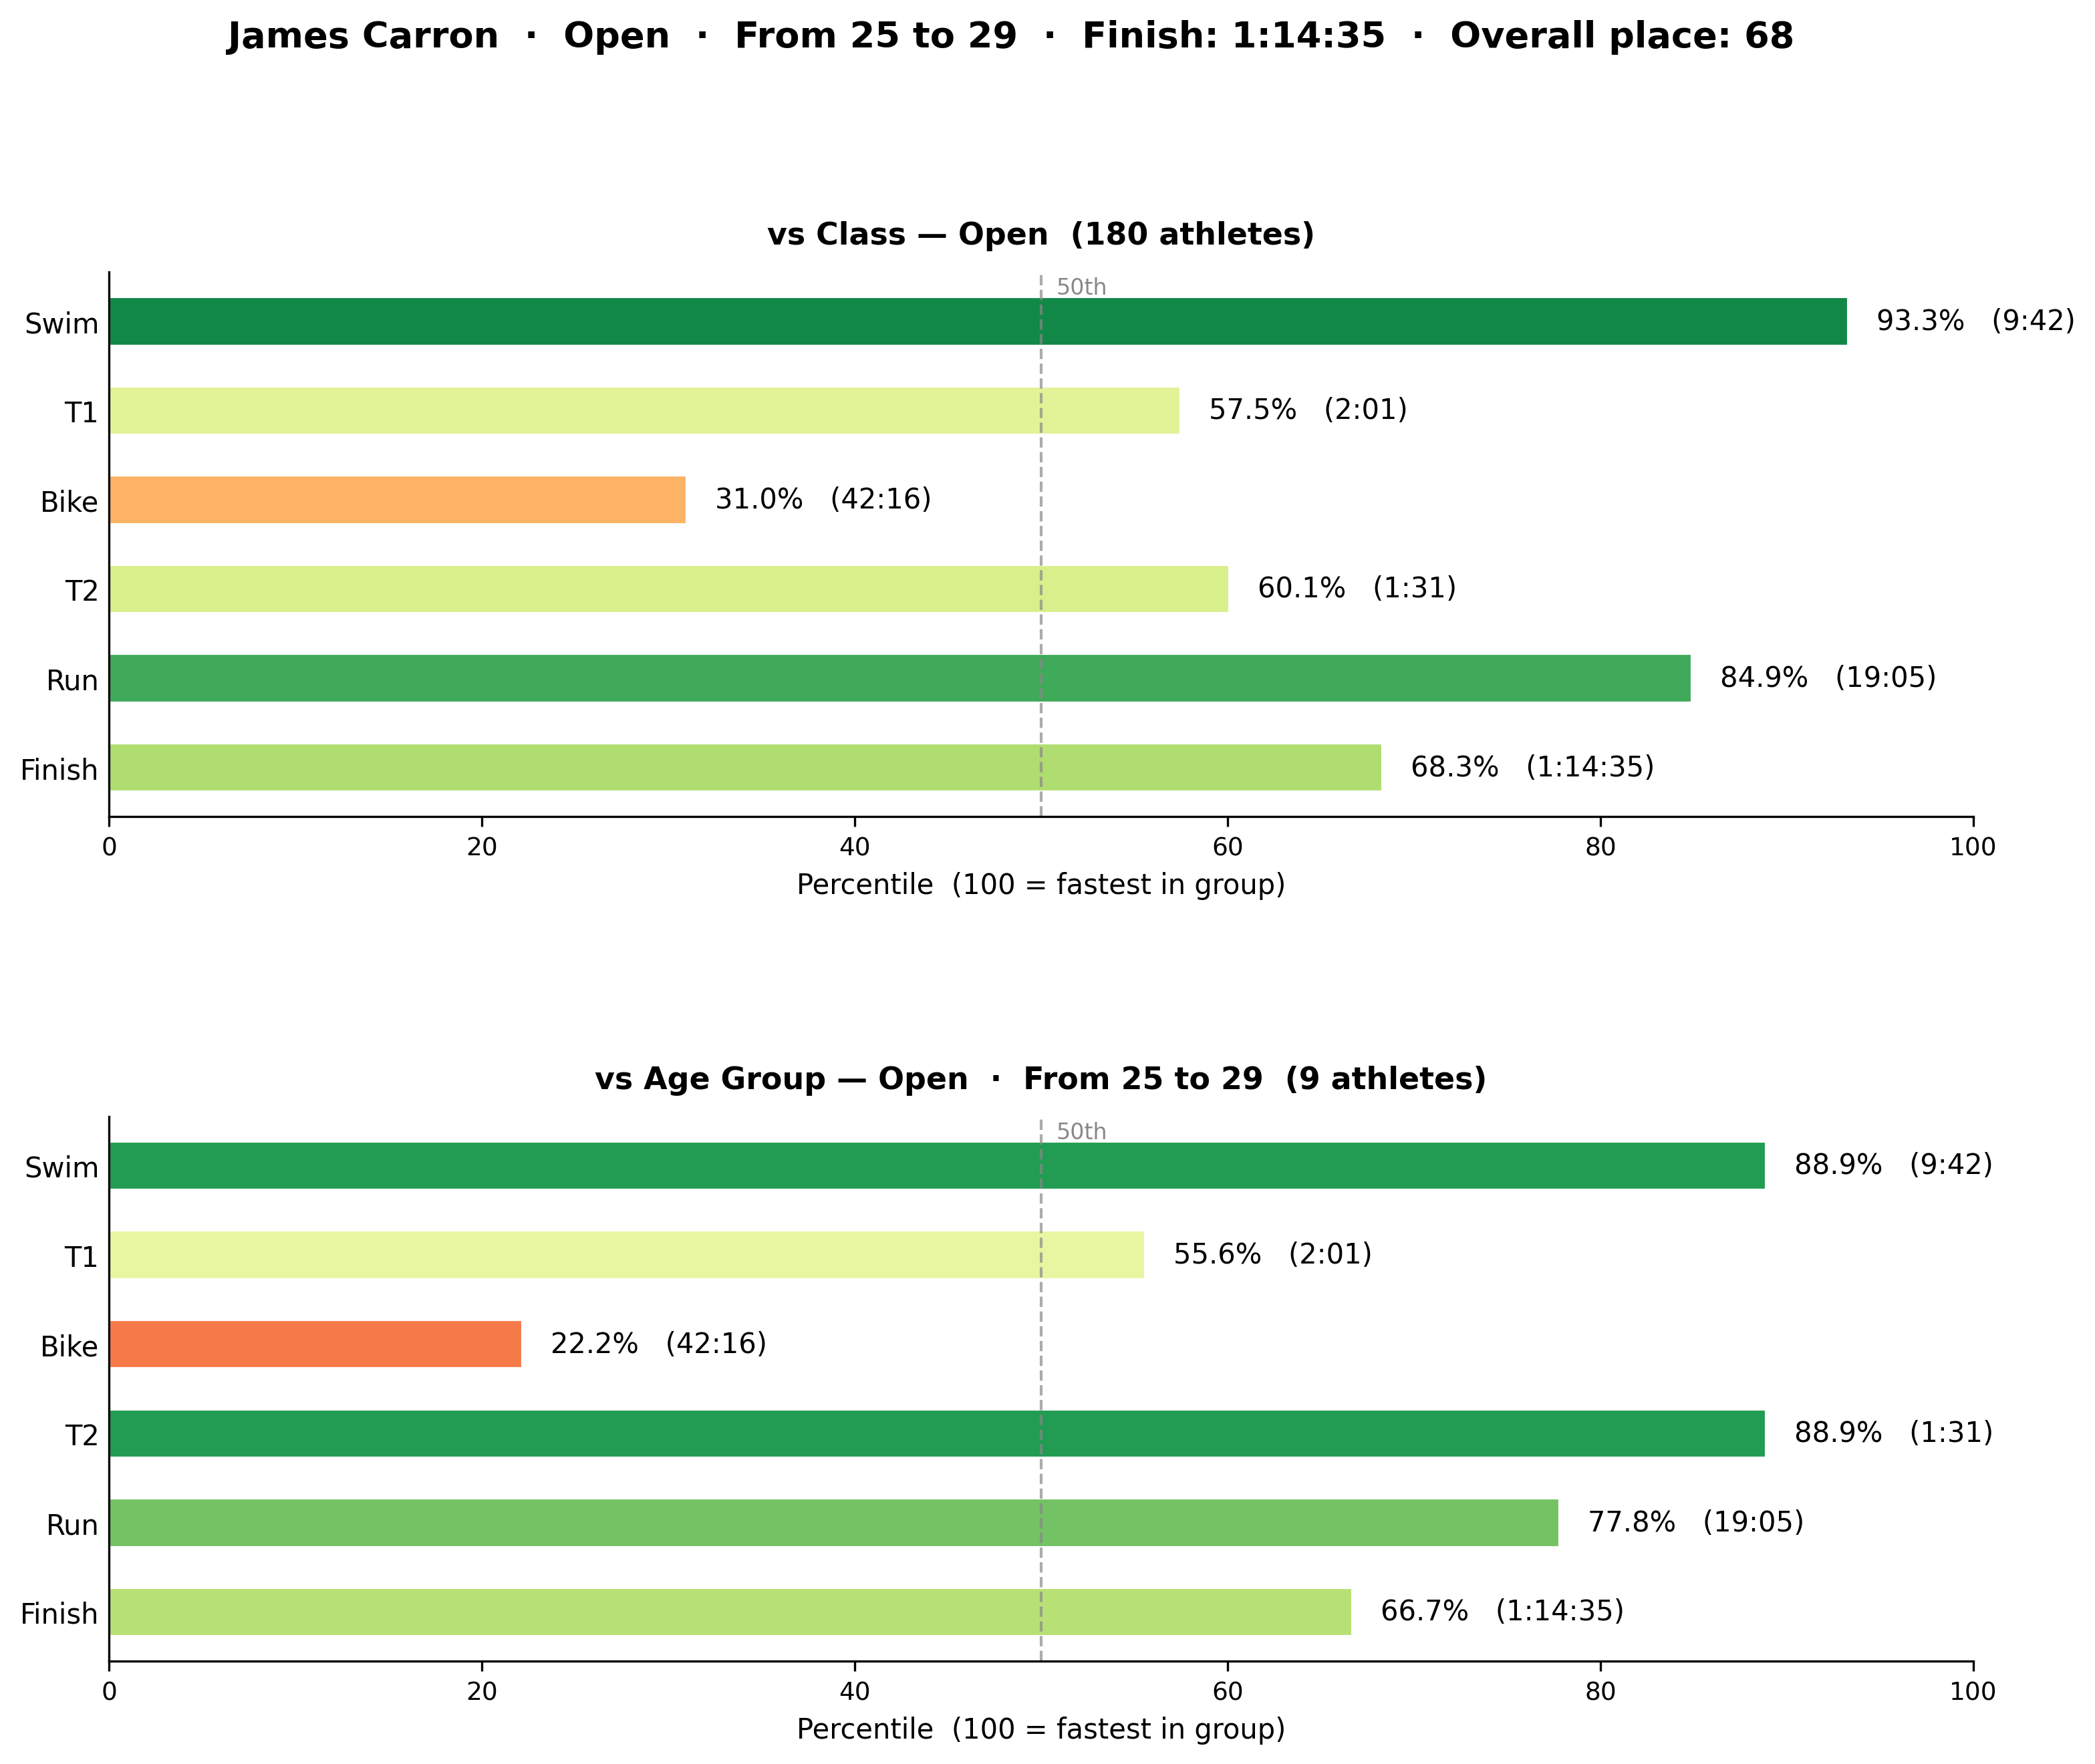

In [42]:
plot_athlete('James Carron', df)

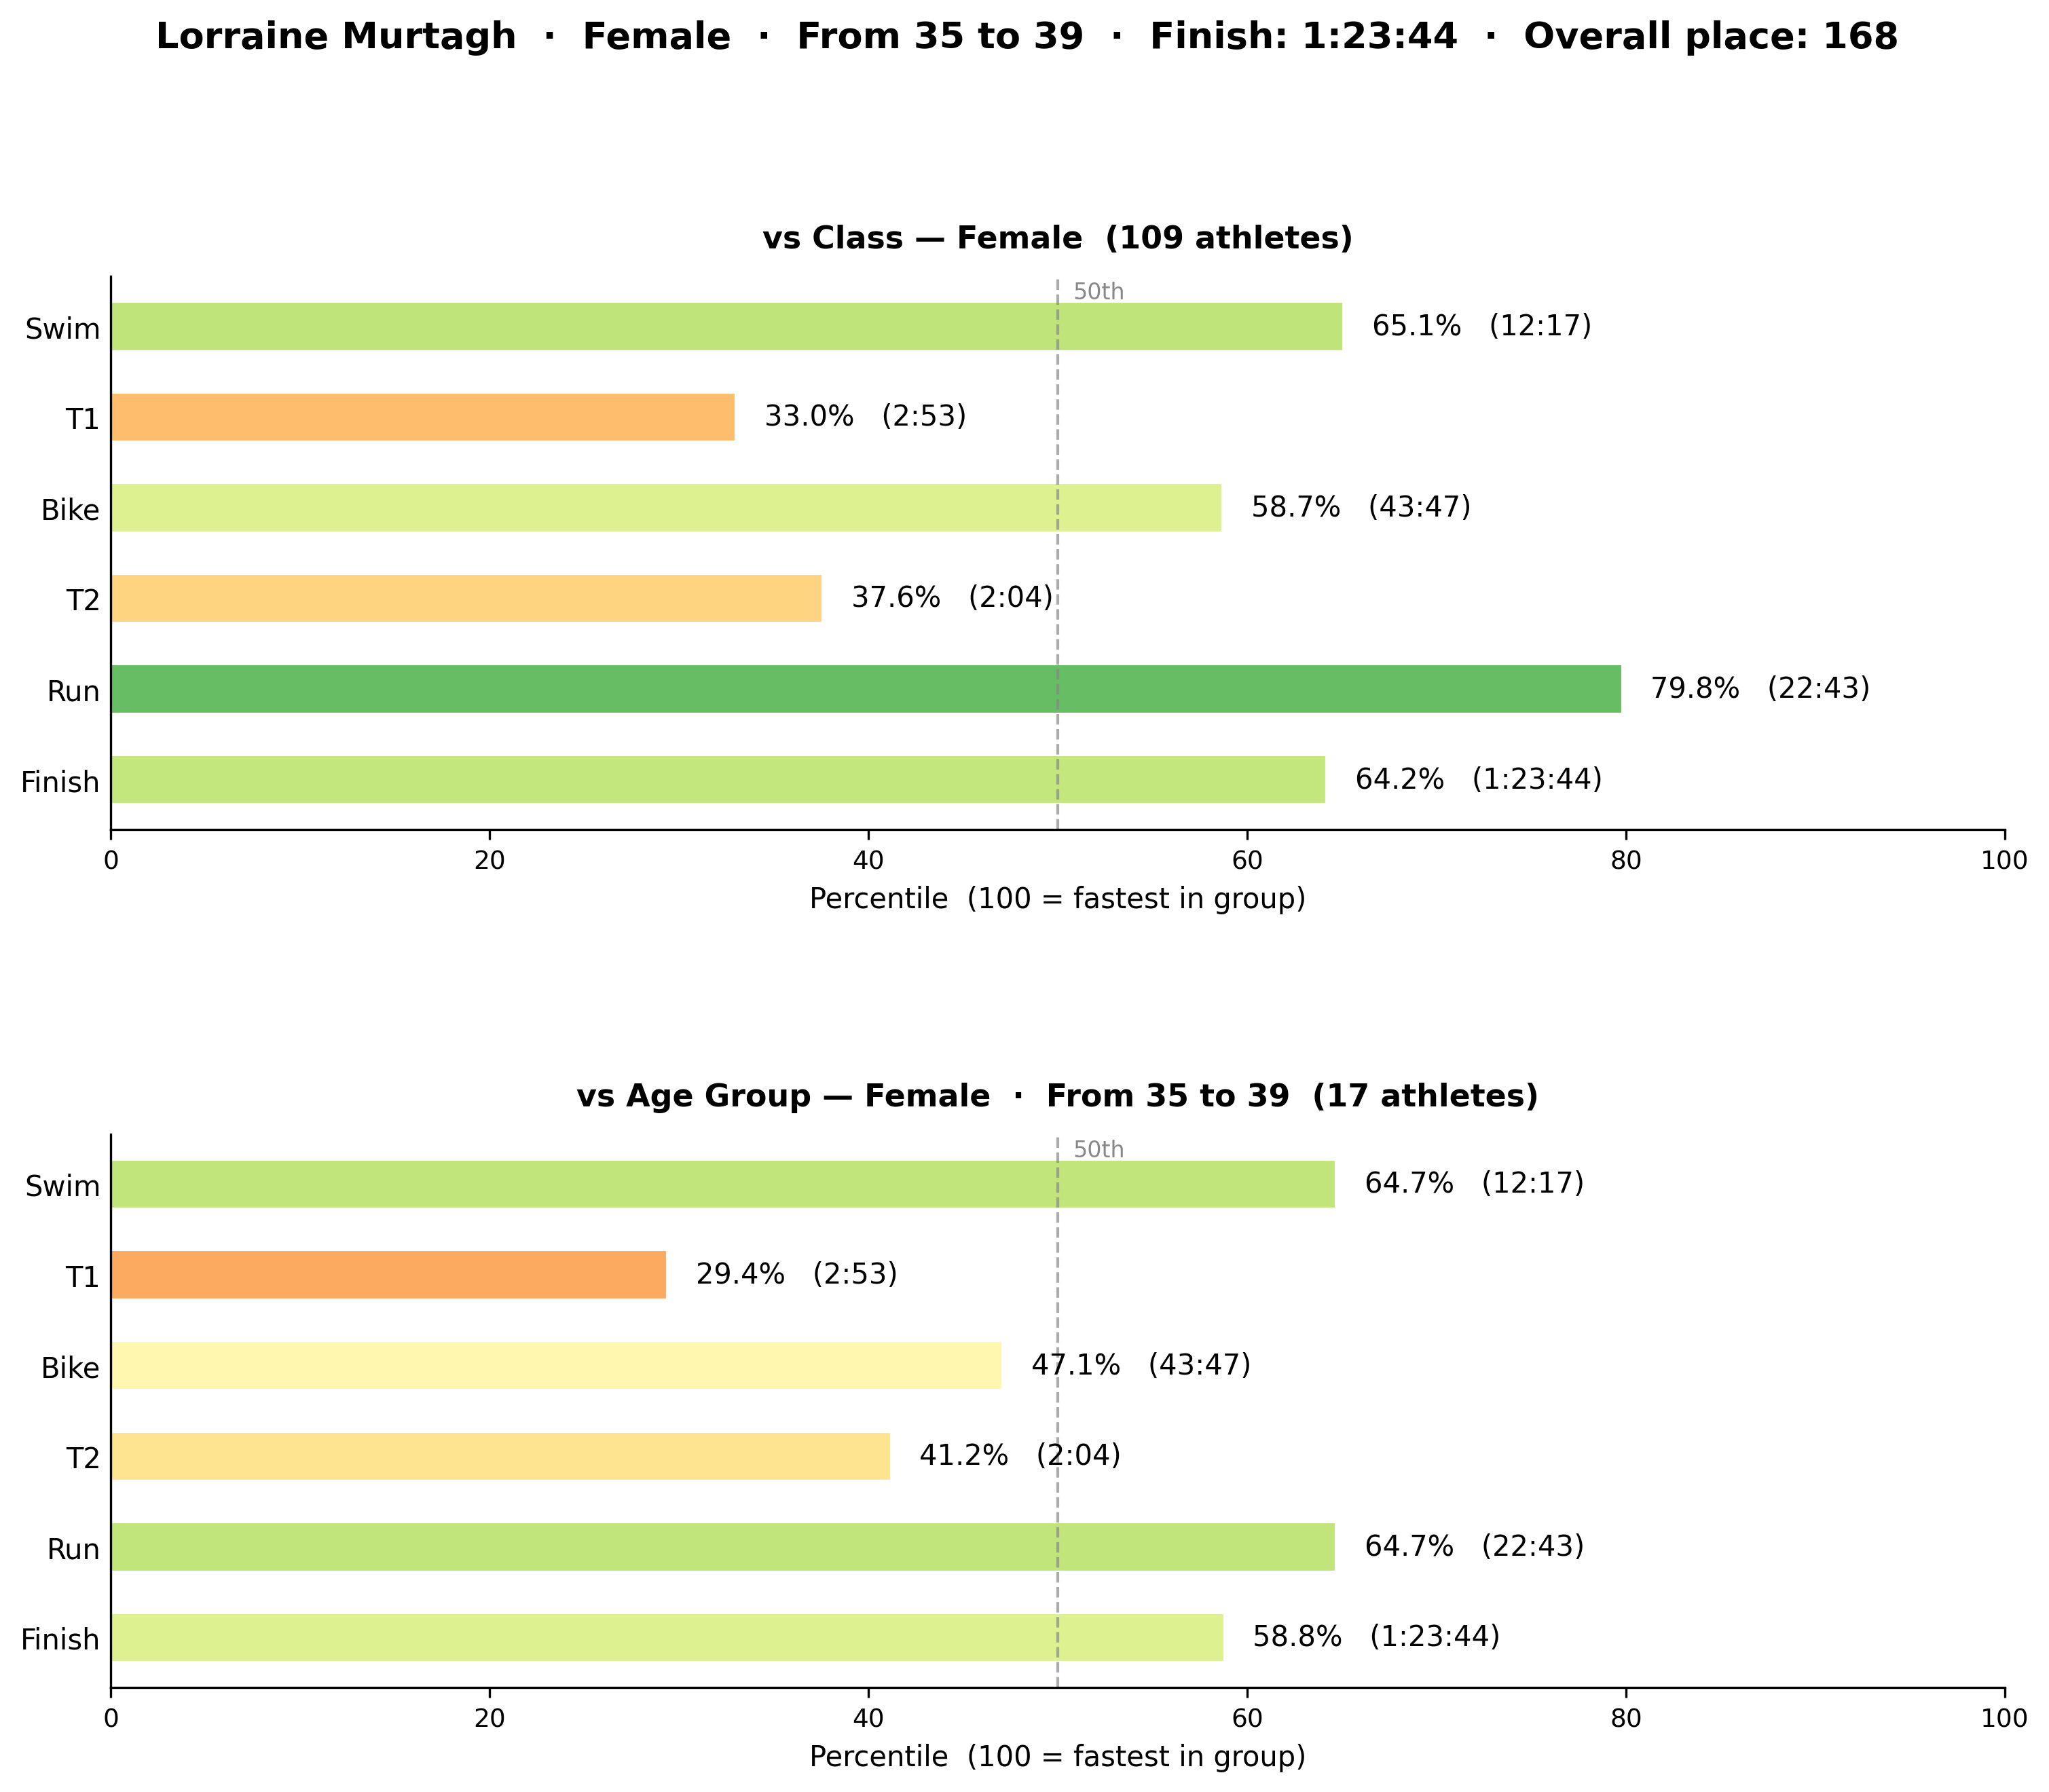

In [41]:
plot_athlete('Lorraine Murtagh', df)

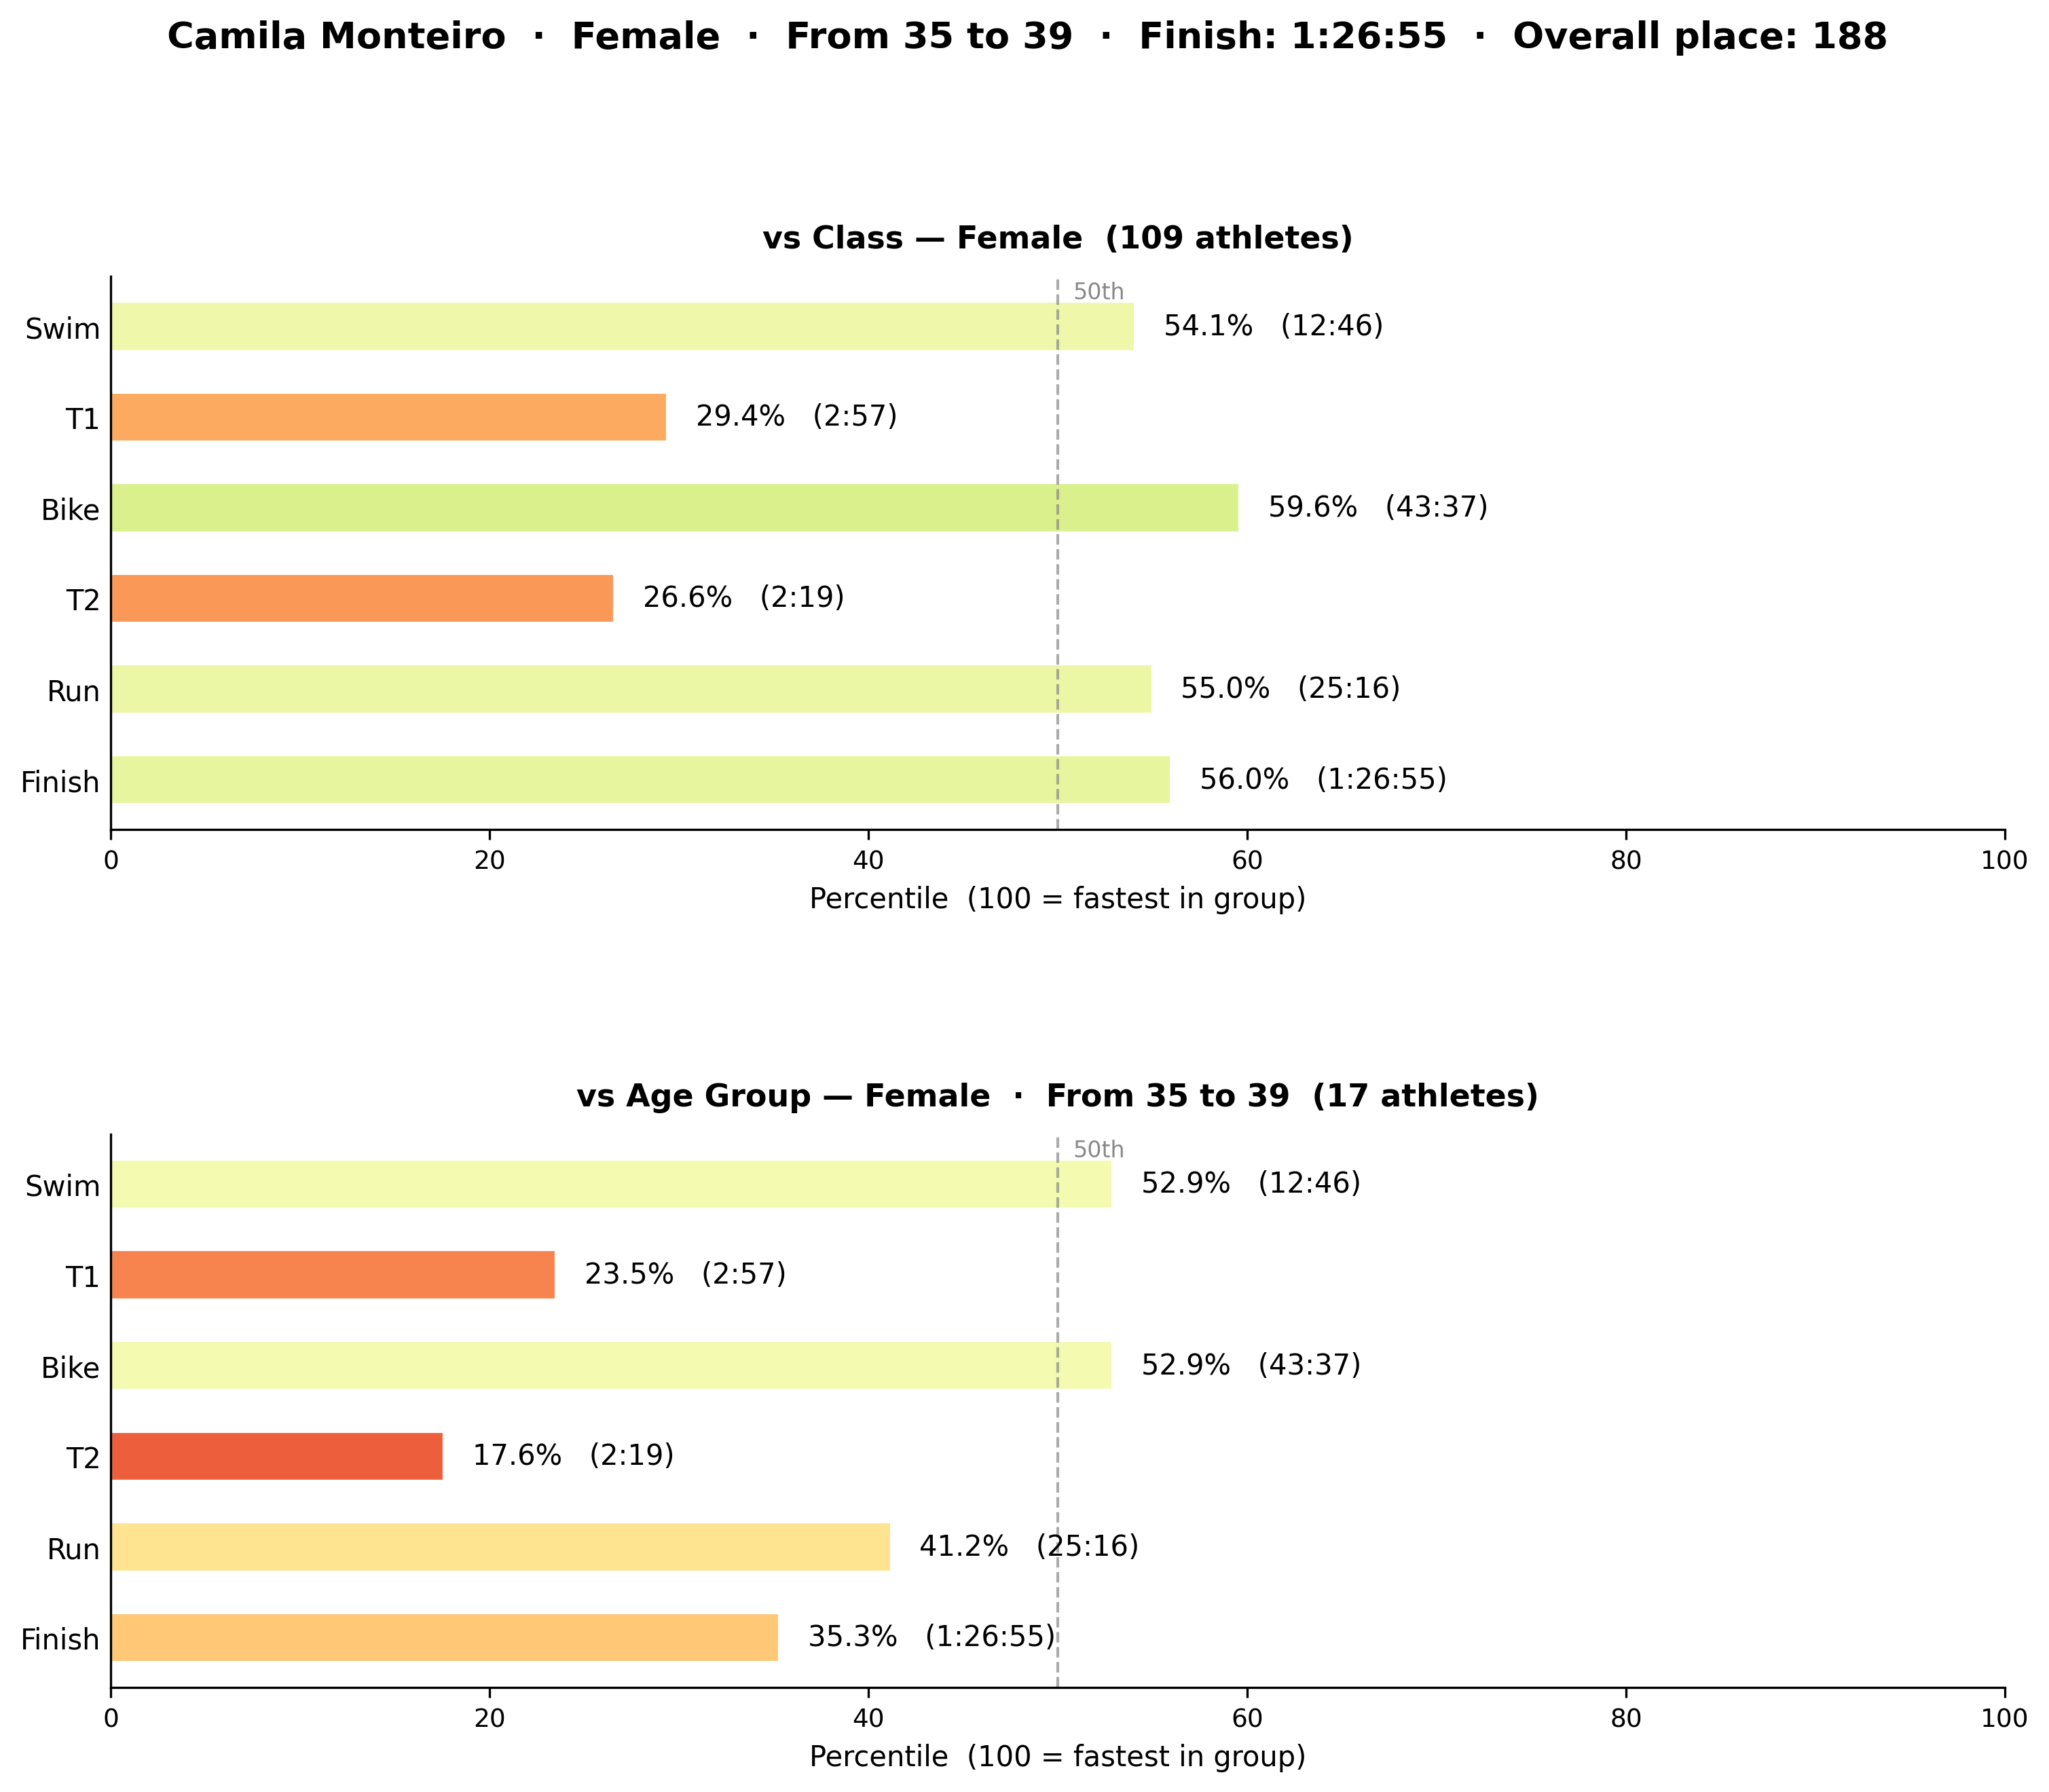

In [46]:
plot_athlete('Camila Monteiro', df)

## Quick sanity checks

In [ ]:
# Top 10 finishers
df.sort_values('Finish').head(10)[['Place', 'Bib', 'Name', 'Age_Group', 'Class', 'Club', 'Finish']]

In [ ]:
# Breakdown by class
df['Class'].value_counts()

In [ ]:
# Fastest swim, bike, and run splits
for col in ['Swim', 'Bike', 'Run']:
    idx = df[col].idxmin()
    row = df.loc[idx]
    print(f'Fastest {col}: {row["Name"]} — {row[col]}')